## 1. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV,
    StratifiedKFold,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.metrics.cluster import contingency_matrix
from scipy.stats import randint
import xgboost as xgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams["figure.dpi"] = 120

BASE_DIR   = os.path.abspath("..")
DATA_DIR   = os.path.join(BASE_DIR, "data")
PLOTS_DIR  = os.path.join(BASE_DIR, "plots")
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(PLOTS_DIR,  exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42

## 2. Load Data


In [2]:
X    = pd.read_csv(os.path.join(DATA_DIR, "executions_features_scaled.csv"))
meta = pd.read_csv(os.path.join(DATA_DIR, "executions_clustered.csv"))
raw  = pd.read_csv(os.path.join(DATA_DIR, "executions.csv"))

# Sanity checks
assert len(X) == len(meta) == len(raw), f"Row mismatch: X={len(X)}, meta={len(meta)}, raw={len(raw)}"
assert "cluster" in meta.columns, "No 'cluster' column in executions_clustered.csv"

X = X.drop(columns=["severity_ordinal"])

y       = meta["cluster"].values
K       = len(np.unique(y))
pattern = raw["pattern"].values   # kept for contingency matrix only

print(f"Feature matrix  : {X.shape}")
print(f"Null check      : {X.isnull().sum().sum()} nulls")
print(f"Clusters (k)    : {K}")
print(f"\nCluster distribution:")
dist = pd.Series(y).value_counts().sort_index()
print(dist.to_string())
print(f"\nImbalance ratio (max/min): {dist.max()/dist.min():.1f}x")


Feature matrix  : (9400, 22)
Null check      : 0 nulls
Clusters (k)    : 7

Cluster distribution:
0     400
1     800
2    1600
3     200
4    2600
5    2400
6    1400

Imbalance ratio (max/min): 13.0x


## 3. Class Balance Check

Visualise cluster sizes before training. Heavy imbalance justifies
`class_weight='balanced'` in Random Forest and `scale_pos_weight` in XGBoost.


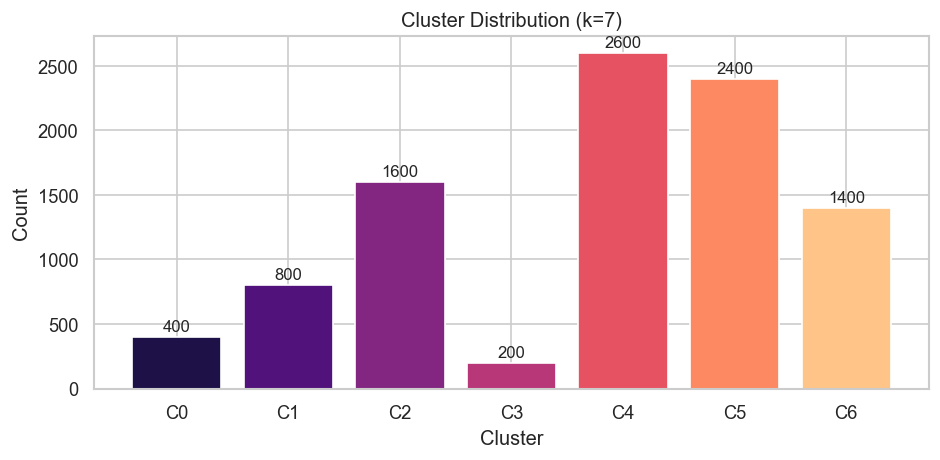

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
cluster_counts = pd.Series(y).value_counts().sort_index()
bars = ax.bar(
    [f"C{i}" for i in cluster_counts.index],
    cluster_counts.values,
    color=sns.color_palette("magma", K),
    edgecolor="white"
)
for bar, val in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha="center", va="bottom", fontsize=10)

ax.set_title(f"Cluster Distribution (k={K})", fontsize=12)
ax.set_xlabel("Cluster")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f"cluster_distribution_k{K}.png"), dpi=150)
plt.show()


## 4. Train / Validation / Test Split

**70% train — 15% validation — 15% test**, all stratified on cluster label.

- Validation set: used for hyperparameter tuning and overfitting check
- Test set: touched once only, for final reported metrics


In [4]:
# Step 1: 70% train, 30% temp
X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X, y, np.arange(len(X)),
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# Step 2: split temp 50/50 → 15% val, 15% test
X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp, y_temp, idx_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Train : {len(X_train):,} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"Val   : {len(X_val):,} rows ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test  : {len(X_test):,} rows ({len(X_test)/len(X)*100:.0f}%)")

# Verify stratification
for split_name, split_y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    dist = pd.Series(split_y).value_counts(normalize=True).sort_index()
    print(f"\n{split_name} class proportions:")
    print(dist.round(3).to_string())


Train : 6,580 rows (70%)
Val   : 1,410 rows (15%)
Test  : 1,410 rows (15%)

Train class proportions:
0    0.043
1    0.085
2    0.170
3    0.021
4    0.277
5    0.255
6    0.149

Val class proportions:
0    0.043
1    0.085
2    0.170
3    0.021
4    0.277
5    0.255
6    0.149

Test class proportions:
0    0.043
1    0.085
2    0.170
3    0.021
4    0.277
5    0.255
6    0.149


## 5. Evaluation Helper

In [5]:
def report(y_true, y_pred, split_name):
    print(f"\n{'='*50}")
    print(f"  {split_name}")
    print(f"{'='*50}")
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  (weighted)")
    print(f"  Recall    : {rec:.4f}  (weighted)")
    print(f"  F1        : {f1:.4f}  (weighted)")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    return f1


## 6. Random Forest

### 6a. Baseline with Cross-Validation

Run 5-fold stratified CV on training data before any tuning.
Establishes a baseline F1 and variance estimate.


In [6]:
rf_base = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf_base, X_train, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1)

print(f"RF Baseline CV F1 (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold: {cv_scores.round(4)}")


RF Baseline CV F1 (5-fold): 1.0000 ± 0.0000
Per-fold: [1. 1. 1. 1. 1.]


### 6b. Hyperparameter Tuning — RandomizedSearchCV

In [7]:
param_dist = {
    "n_estimators"    : randint(100, 500),
    "max_depth"       : [None, 5, 10, 15, 20],
    "min_samples_leaf": randint(1, 10),
    "max_features"    : ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=cv,
    scoring="f1_weighted",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)

print(f"\nBest params : {rf_search.best_params_}")
print(f"Best CV F1  : {rf_search.best_score_:.4f}")
rf_best = rf_search.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params : {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'n_estimators': 288}
Best CV F1  : 1.0000


### 6c. Overfitting Check — Train vs Validation

In [8]:
y_pred_train = rf_best.predict(X_train)
y_pred_val   = rf_best.predict(X_val)

train_f1 = report(y_train, y_pred_train, "RF — Train")
val_f1   = report(y_val,   y_pred_val,   "RF — Validation")

gap = train_f1 - val_f1
print(f"\nTrain F1: {train_f1:.4f} | Val F1: {val_f1:.4f} | Gap: {gap:.4f}")

if gap > 0.05:
    print("⚠  Overfitting detected — consider increasing min_samples_leaf or reducing max_depth.")
else:
    print("✓  Gap acceptable — model generalises well.")



  RF — Train
  Accuracy  : 1.0000
  Precision : 1.0000  (weighted)
  Recall    : 1.0000  (weighted)
  F1        : 1.0000  (weighted)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       280
           1       1.00      1.00      1.00       560
           2       1.00      1.00      1.00      1120
           3       1.00      1.00      1.00       140
           4       1.00      1.00      1.00      1820
           5       1.00      1.00      1.00      1680
           6       1.00      1.00      1.00       980

    accuracy                           1.00      6580
   macro avg       1.00      1.00      1.00      6580
weighted avg       1.00      1.00      1.00      6580


  RF — Validation
  Accuracy  : 1.0000
  Precision : 1.0000  (weighted)
  Recall    : 1.0000  (weighted)
  F1        : 1.0000  (weighted)

Classification Report:
              precision    recall  f1-score   support

           0       1.00    

## 7. XGBoost — Comparison

Same CV protocol as Random Forest for a fair comparison.


In [9]:
xgb_param_dist = {
    "n_estimators"  : randint(100, 400),
    "max_depth"     : randint(3, 10),
    "learning_rate" : [0.01, 0.05, 0.1, 0.2],
    "subsample"     : [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(
        use_label_encoder=False,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=cv,
    scoring="f1_weighted",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_

print(f"\nXGB Best params : {xgb_search.best_params_}")
print(f"XGB Best CV F1  : {xgb_search.best_score_:.4f}")
print(f"RF  Best CV F1  : {rf_search.best_score_:.4f}")

y_pred_val_xgb = xgb_best.predict(X_val)
xgb_val_f1 = f1_score(y_val, y_pred_val_xgb, average="weighted", zero_division=0)
print(f"\nVal F1 — RF : {val_f1:.4f}")
print(f"Val F1 — XGB: {xgb_val_f1:.4f}")

best_model = rf_best if val_f1 >= xgb_val_f1 else xgb_best
best_model_name = "RandomForest" if val_f1 >= xgb_val_f1 else "XGBoost"
print(f"\n✓ Selected: {best_model_name}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

XGB Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 370, 'subsample': 1.0}
XGB Best CV F1  : 1.0000
RF  Best CV F1  : 1.0000

Val F1 — RF : 1.0000
Val F1 — XGB: 1.0000

✓ Selected: RandomForest


## 8. Final Evaluation on Test Set

**Run once only.** Test set was not touched during tuning.


In [10]:
y_pred_test = best_model.predict(X_test)
test_f1 = report(y_test, y_pred_test, f"Test — {best_model_name}")

print(f"\n{'='*50}")
print(f"  FINAL TEST F1 ({best_model_name}): {test_f1:.4f}")
print(f"{'='*50}")



  Test — RandomForest
  Accuracy  : 1.0000
  Precision : 1.0000  (weighted)
  Recall    : 1.0000  (weighted)
  F1        : 1.0000  (weighted)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00       120
           2       1.00      1.00      1.00       240
           3       1.00      1.00      1.00        30
           4       1.00      1.00      1.00       390
           5       1.00      1.00      1.00       360
           6       1.00      1.00      1.00       210

    accuracy                           1.00      1410
   macro avg       1.00      1.00      1.00      1410
weighted avg       1.00      1.00      1.00      1410


  FINAL TEST F1 (RandomForest): 1.0000


## 9. Confusion Matrix (Test Set)

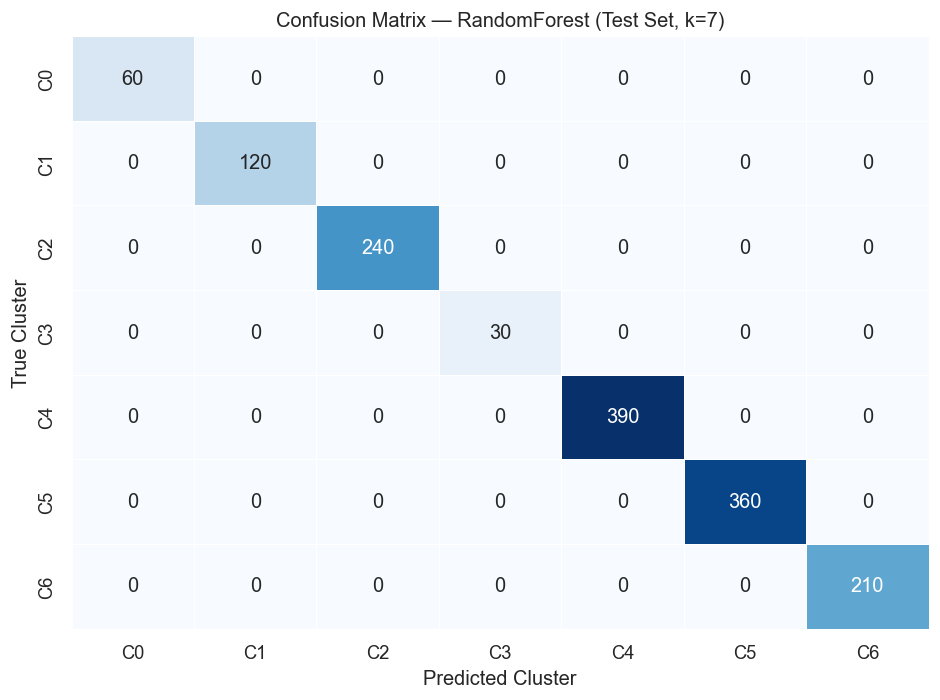

In [11]:
cm = confusion_matrix(y_test, y_pred_test)
labels = [f"C{i}" for i in range(K)]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, ax=ax,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels,
    linewidths=0.4, linecolor="white", cbar=False
)
ax.set_title(f"Confusion Matrix — {best_model_name} (Test Set, k={K})", fontsize=12)
ax.set_xlabel("Predicted Cluster")
ax.set_ylabel("True Cluster")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f"confusion_matrix_k{K}.png"), dpi=150)
plt.show()


## 10. Contingency Matrix — Cluster × Pattern (Test Set)

Uses **test-set indices only** to avoid shape mismatch.
Shows which patterns dominate each cluster — used for semantic naming.


Contingency Matrix — pattern × cluster (test set):


,C0,C1,C2,C3,C4,C5,C6
constant_folding,60,0,240,0,284,0,119
dead_code,0,0,0,30,0,0,0
early_return,0,0,0,0,0,360,0
expensive_calls,0,28,0,0,0,0,0
hot_loop,0,56,0,0,0,0,0
loop_invariant,0,0,0,0,44,0,0
nested_loops,0,36,0,0,0,0,0
repeated_computation,0,0,0,0,0,0,28
string_concat_loop,0,0,0,0,35,0,0
unused_vars,0,0,0,0,27,0,63


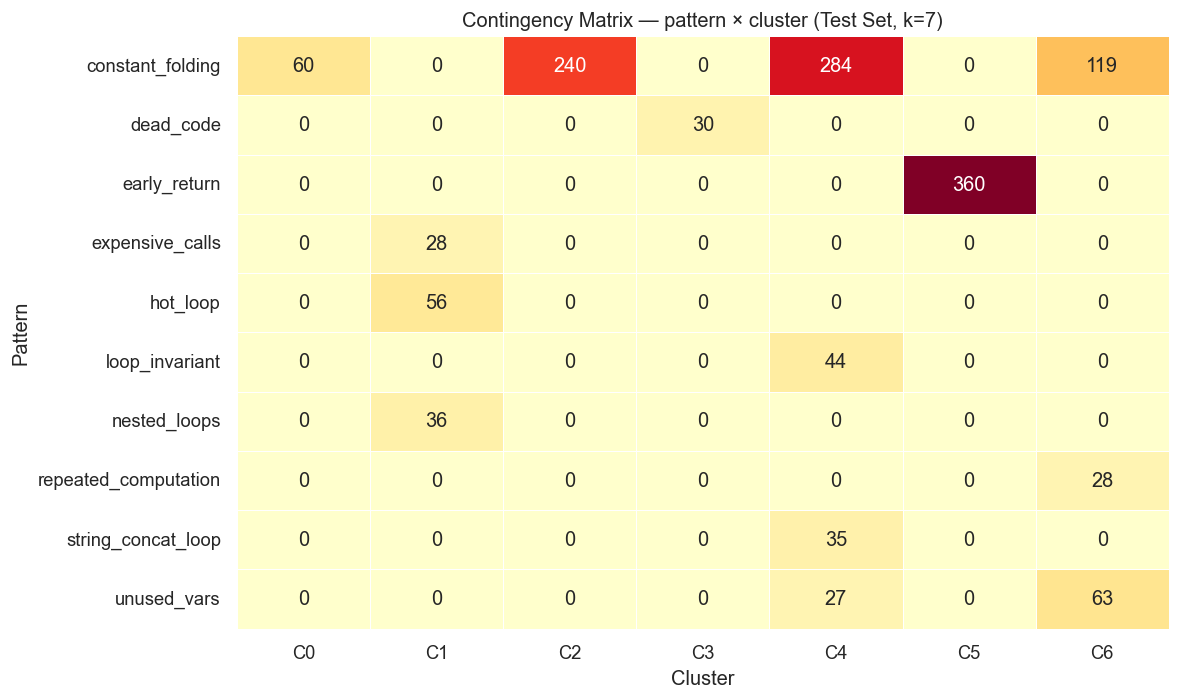

In [12]:
# Use test indices to align pattern labels correctly
pattern_test = pattern[idx_test]

cm_cont = contingency_matrix(pattern_test, y_pred_test)
pattern_labels = sorted(np.unique(pattern_test))
cluster_labels = [f"C{i}" for i in range(K)]

cm_cont_df = pd.DataFrame(
    cm_cont,
    index=pattern_labels,
    columns=cluster_labels
)

print("Contingency Matrix — pattern × cluster (test set):")
display(cm_cont_df)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    cm_cont_df, ax=ax,
    annot=True, fmt="d", cmap="YlOrRd",
    linewidths=0.4, linecolor="white", cbar=False
)
ax.set_title(f"Contingency Matrix — pattern × cluster (Test Set, k={K})", fontsize=12)
ax.set_xlabel("Cluster")
ax.set_ylabel("Pattern")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f"contingency_matrix_k{K}.png"), dpi=150)
plt.show()


## 11. Feature Importance

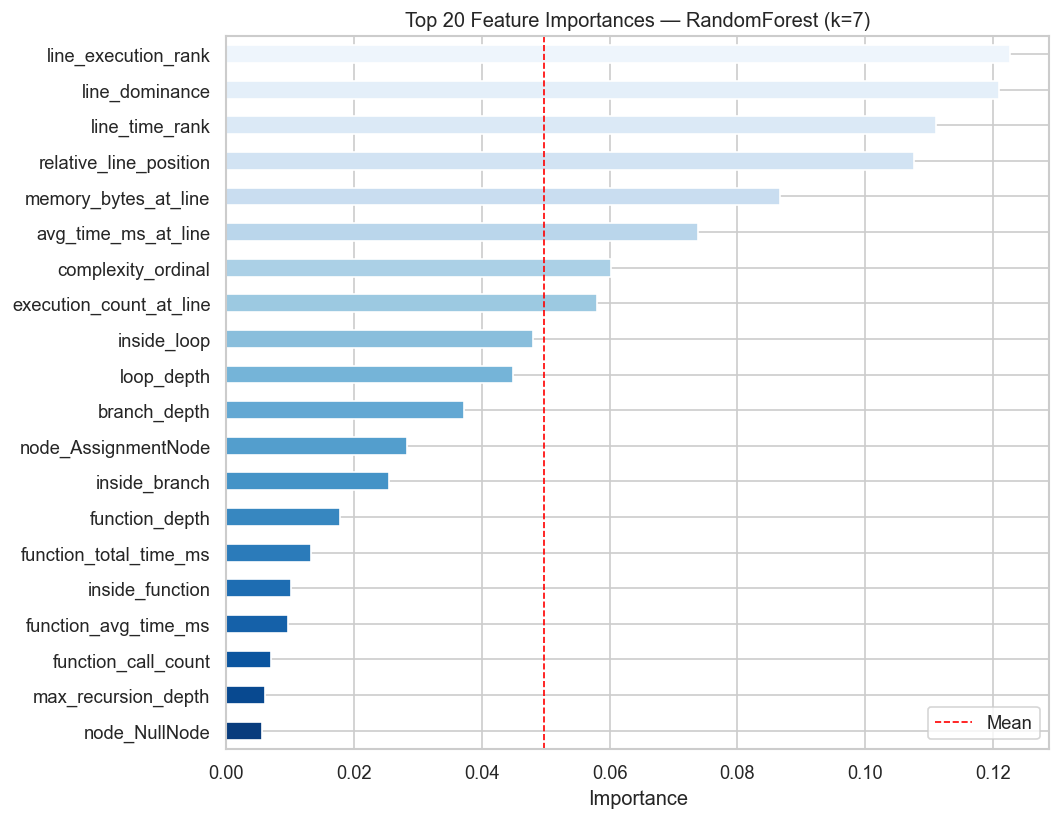


Top 10 features:
line_execution_rank        0.1226
line_dominance             0.1210
line_time_rank             0.1111
relative_line_position     0.1077
memory_bytes_at_line       0.0868
avg_time_ms_at_line        0.0738
complexity_ordinal         0.0603
execution_count_at_line    0.0580
inside_loop                0.0479
loop_depth                 0.0449


In [13]:
# Works for both RF and XGB
importances = best_model.feature_importances_
imp = pd.Series(importances, index=X.columns).nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colors = sns.color_palette("Blues_r", len(imp))
imp.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title(f"Top 20 Feature Importances — {best_model_name} (k={K})", fontsize=12)
ax.set_xlabel("Importance")
ax.axvline(imp.mean(), color="red", linestyle="--", linewidth=1, label="Mean")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f"feature_importance_k{K}.png"), dpi=150)
plt.show()

print("\nTop 10 features:")
print(imp.tail(10).sort_values(ascending=False).round(4).to_string())


## 12. Semantic Cluster Naming

Derive dominant pattern per cluster from the full contingency matrix,
then assign a human-readable archetype name.

**Edit `CLUSTER_NAMES` below after inspecting the contingency matrix.**


In [14]:
# Full-dataset contingency for naming (all rows, true labels)
cm_full = contingency_matrix(pattern, y)
pattern_labels_full = sorted(np.unique(pattern))

cm_full_df = pd.DataFrame(
    cm_full,
    index=pattern_labels_full,
    columns=[f"C{i}" for i in range(K)]
)

# Dominant pattern per cluster
dominant = cm_full_df.idxmax(axis=0)
print("Dominant pattern per cluster:")
print(dominant.to_string())


Dominant pattern per cluster:
C0    constant_folding
C1            hot_loop
C2    constant_folding
C3           dead_code
C4    constant_folding
C5        early_return
C6    constant_folding


In [15]:
# ── EDIT THIS AFTER INSPECTING THE CONTINGENCY MATRIX ──────────────────────
# Map cluster int → semantic archetype name
# Default: use dominant pattern name. Override with descriptive names below.

CLUSTER_NAMES = {i: f"C{i}_{dominant[f'C{i}']}" for i in range(K)}

# Example overrides (uncomment and adjust after inspection):
# CLUSTER_NAMES = {
#     0: "static_dead_weight",
#     1: "loop_hotspot",
#     2: "constant_folding_bulk",
#     3: "structural_smell",
#     4: "repeated_work",
#     5: "early_exit_opportunity",
# }

print("\nCluster name map:")
for k, v in CLUSTER_NAMES.items():
    print(f"  {k} → {v}")

# Save name map
name_map_path = os.path.join(MODELS_DIR, f"cluster_names_k{K}.json")
import json
with open(name_map_path, "w") as f:
    json.dump(CLUSTER_NAMES, f, indent=2)
print(f"\nSaved: {name_map_path}")



Cluster name map:
  0 → C0_constant_folding
  1 → C1_hot_loop
  2 → C2_constant_folding
  3 → C3_dead_code
  4 → C4_constant_folding
  5 → C5_early_return
  6 → C6_constant_folding

Saved: /Users/stha_manik/Projects/OptiLang/optilang/optilang/ml/models/cluster_names_k7.json


## 13. Model Comparison Summary

In [16]:
results = {
    "RandomForest": {
        "CV F1 (mean)": rf_search.best_score_,
        "Val F1"      : val_f1,
    }
}

results["XGBoost"] = {
    "CV F1 (mean)": xgb_search.best_score_,
    "Val F1"      : xgb_val_f1,
}

results_df = pd.DataFrame(results).T
results_df["Test F1"] = None
results_df.loc[best_model_name, "Test F1"] = test_f1

print("\nModel Comparison:")
display(results_df.round(4))
print(f"\n✓ Best model: {best_model_name} (Test F1: {test_f1:.4f})")



Model Comparison:


,CV F1 (mean),Val F1,Test F1
RandomForest,1.0,1.0,1.0
XGBoost,1.0,1.0,None



✓ Best model: RandomForest (Test F1: 1.0000)


## 14. Save Best Model

In [17]:
model_path = os.path.join(MODELS_DIR, f"classifier_{best_model_name.lower()}_k{K}.pkl")
joblib.dump(best_model, model_path)
print(f"Saved model : {model_path}")
print(f"Saved names : {name_map_path}")
print(f"\nTo load:")
print(f"  model = joblib.load('{model_path}')")
print(f"  names = json.load(open('{name_map_path}'))")


Saved model : /Users/stha_manik/Projects/OptiLang/optilang/optilang/ml/models/classifier_randomforest_k7.pkl
Saved names : /Users/stha_manik/Projects/OptiLang/optilang/optilang/ml/models/cluster_names_k7.json

To load:
  model = joblib.load('/Users/stha_manik/Projects/OptiLang/optilang/optilang/ml/models/classifier_randomforest_k7.pkl')
  names = json.load(open('/Users/stha_manik/Projects/OptiLang/optilang/optilang/ml/models/cluster_names_k7.json'))


## 15. Inference Example

How to classify a new suggestion at runtime.


In [18]:
import json

model      = joblib.load(model_path)
names      = json.load(open(name_map_path))

# Example: use first row of test set as a new suggestion
new_suggestion = X_test.iloc[[0]]

predicted_cluster = model.predict(new_suggestion)[0]
predicted_proba   = model.predict_proba(new_suggestion)[0]
cluster_name      = names[str(predicted_cluster)]

print(f"Predicted cluster : {predicted_cluster} → '{cluster_name}'")
print(f"Confidence        : {predicted_proba.max():.2%}")
print(f"\nProbability per cluster:")
for i, p in enumerate(predicted_proba):
    print(f"  C{i} ({names[str(i)]}): {p:.4f}")


Predicted cluster : 1 → 'C1_hot_loop'
Confidence        : 100.00%

Probability per cluster:
  C0 (C0_constant_folding): 0.0000
  C1 (C1_hot_loop): 1.0000
  C2 (C2_constant_folding): 0.0000
  C3 (C3_dead_code): 0.0000
  C4 (C4_constant_folding): 0.0000
  C5 (C5_early_return): 0.0000
  C6 (C6_constant_folding): 0.0000
